# Neural Networks & Back Propagation

Follows the [youtube video][1] from [Andrej Karpathy][2] 

[1]: https://www.youtube.com/watch?v=VMj-3S1tku0
[2]: https://www.youtube.com/@AndrejKarpathy

## Setup

Before running this notebook run these commands
```shell
# Setup venv env for python 3.10 because later versions caused me issues
uv venv -p 3.10

# These are the packages needed to run this notebook
# Version compatibility is terrible
uv pip install matplotlib numpy==1.26.4 torch==2.2.2 ipykernel graphviz
```

In [43]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
def f(x):
    return 3*x**2 - 4*x + 5

In [45]:
f(3.0)

20.0

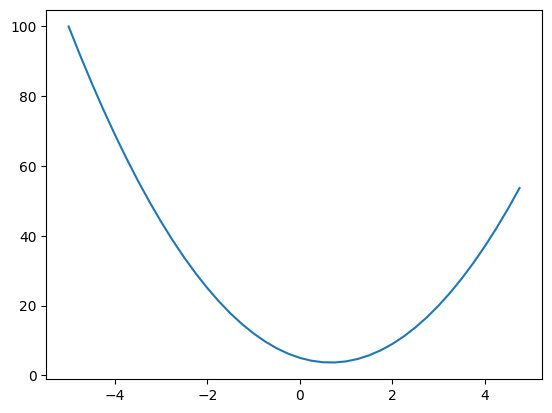

In [46]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [47]:
# derivative of f(x) is
def d_f(x):
    return 6*x - 4



h = 0.001
x = 3.0
print("approx derivative", (f(x + h) - f(x)) / h)
print("using derivative", d_f(x))

approx derivative 14.00300000000243
using derivative 14.0


In [48]:
# derivative of f(x) is
def d_f(x):
    return 6*x - 4

d_f(x)

14.0

In [49]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0
# d = a * b + c
# print(d)

d1 = a * b + c
a += h
d2 = a * b + c

print("d1", d1)
print("d2", d2)
print("slope", (d2 - d1) / h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [50]:
from typing import Union

class Value:
    def __init__(self, value, _children=(), _op="", label="#"):
        self.value = value
        self.grad = 0.0
        self.label = label
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.value}, grad={self.grad})"
        # return f"Value({self.value}, {self.label}, {self._op})"

    def __add__(self, other: Union["Value", float]):
        other = other if isinstance(other, Value) else Value(other)

        label = "#"
        if self.label != "#" and other.label != "#":
            label = self.label + "-" + other.label

        out = Value(self.value + other.value, (self, other), "+", label)

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other: Union["Value", float]):
        other = other if isinstance(other, Value) else Value(other)

        label = "#"
        if self.label != "#" and other.label != "#":
            label = self.label + "-" + other.label

        out = Value(self.value * other.value, (self, other), "*", label)

        def _backward():
            self.grad += other.value * out.grad
            other.grad += self.value * out.grad

        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"

        label = "#"
        if self.label != "#" and other.label != "#":
            label = self.label + "-" + other.label
        out = Value(self.value**other, (self,), _op=f"**{other}", label=label)

        def _backward():
            self.grad += (other * self.value**(other-1)) * out.grad

        out._backward = _backward
        return out

    def relu(self):
        out = Value(0 if self.value < 0 else self.value, (self,), _op="ReLU", label=self.label + "-relu")

        def _backward():
            self.grad += (out.value > 0) * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.value
        tan_h = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(tan_h, (self, ), _op="tanh", label=self.label + "-tanh")

        def _backward():
            self.grad += (1 - tan_h ** 2) * out.grad

        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __rtruediv__(self, other):
        return other * self**-1

a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
print(a, b, c)

e = a * b
d = e + c
f = Value(-2.0, label="f")

L = d * f

Value(data=2.0, grad=0.0) Value(data=-3.0, grad=0.0) Value(data=10.0, grad=0.0)


In [51]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | val %.4f | grad %.4f }" % (n.label, n.value, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

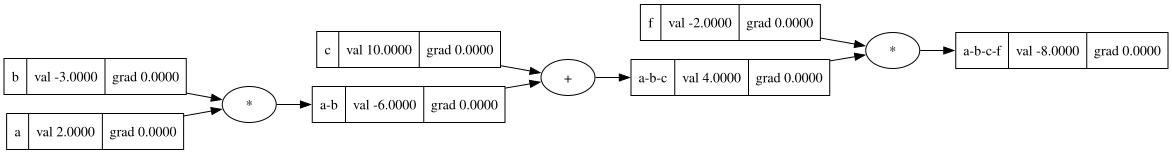

In [52]:

draw_dot(L)

In [53]:
def build_topological_graph(in_node: Value) -> list[Value]:
    topo = []
    seen = set()
    if in_node not in seen:
        seen.add(in_node)
        for c in in_node._prev:
            c_topo = build_topological_graph(c)
            topo.extend(c_topo)
        topo.append(in_node)

    return topo

def back_propagation(in_node: Value):
    topo_list = build_topological_graph(in_node)
    in_node.grad = 1.0
    for n in reversed(topo_list):
        n._backward()

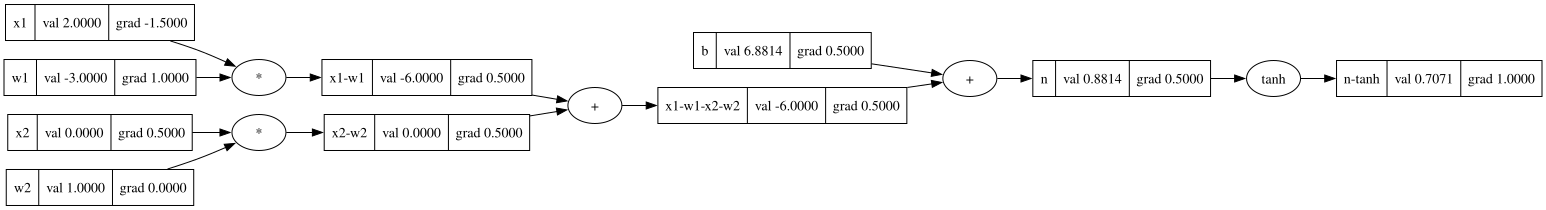

In [54]:
# Inputs
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# Weights
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# Bias
b = Value(6.8813735870195432, label="b")

x1w1 = x1 * w1
x2w2 = x2 * w2
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh()

back_propagation(o)

draw_dot(o)

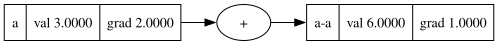

In [55]:
a = Value(3.0, label="a")
b = a + a
back_propagation(b)
draw_dot(b)

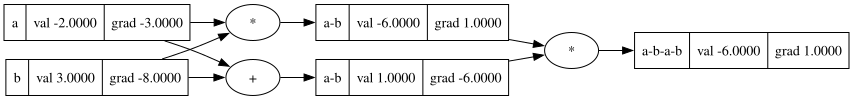

In [56]:
a = Value(-2.0, label="a")
b = Value(3.0, label="b")
d = a * b
e = a + b
f = d * e

back_propagation(f)
draw_dot(f)

In [57]:
import torch

In [58]:
x1 = torch.tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("---")
print("x1", x1.grad.item())
print("x2", x2.grad.item())
print("w1", w1.grad.item())
print("w2", w2.grad.item())

0.7071066904050358
---
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


### Comparison

Note that the results from the custom `Value` class outputs are the same as the `torch.tensor` operations.

**NOTE**: I renamed the Value.data to Value.value but I should have kept it the same as tensor.

In [59]:
import random

class Neuron:
    def __init__(self, _in: int):
        self.weight: list[Value] = [Value(random.uniform(-1, 1), label=f"w{i}") for i in range(_in)]
        self.bias: Value = Value(random.uniform(-1, 1), label="b")

    def __call__(self, x: list[float], *args, **kwds):
        # forward pass
        # w * x + b
        activation = sum(wi * xi for wi, xi in zip(self.weight, x))
        out = activation.tanh()

        return out

    def parameters(self):
        return self.weight + [self.bias]


class Layer:
    def __init__(self, _in: int, _out: int):
        self.neurons = [Neuron(_in) for _ in range(_out)]

    def __call__(self, x: list[float], *args, **kwds):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MultilayerPerceptron:
    def __init__(self, _in: int, _outs: list[int]):
        layer_sizes = [_in] + _outs
        self.layers = [Layer(layer_sizes[i], layer_sizes[i + 1]) for i in range(len(_outs))]

    def __call__(self, x: list[float], *args, **kwds):
        for layer in self.layers:
            x = layer(x)

        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x = [2.0, 3.0, -1.0]
model = MultilayerPerceptron(3, [4, 4, 1])

y = model(x)
print(y)

back_propagation(y)
# draw_dot(y)

Value(data=-0.7736976827601519, grad=0.0)


In [60]:
# print(model.parameters())
print(f"Model has {len(model.parameters())} parameters")

Model has 41 parameters


In [61]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

labels = [1.0, -1.0, -1.0, 1.0]
y_pred: list[Value] = [model(x) for x in xs]

print(y_pred)

[Value(data=-0.7736976827601519, grad=0.0), Value(data=-0.3234154806504906, grad=0.0), Value(data=-0.3511311126235231, grad=0.0), Value(data=-0.8544598467421616, grad=0.0)]


In [62]:
loss = sum([(y_out - y_g_truth)**2 for y_g_truth, y_out in zip(labels, y_pred)])

print("MSE Loss", loss)

back_propagation(loss)
# draw_dot(loss)

MSE Loss Value(data=7.463822237836288, grad=0.0)


In [63]:
"""
These were my outputs at the time of running. You can see the loss move closer and closer to zero

MSE Loss Value(data=4.149186374706559, grad=0.0)
MSE Loss Value(data=3.9604362523468053, grad=0.0)
MSE Loss Value(data=3.1977720309205244, grad=0.0)
MSE Loss Value(data=2.102073245324555, grad=0.0)
MSE Loss Value(data=1.071976925111202, grad=0.0)
MSE Loss Value(data=0.8215303202070161, grad=0.0)
MSE Loss Value(data=0.80947147153443, grad=0.0)
MSE Loss Value(data=0.8549238394921567, grad=0.0)
MSE Loss Value(data=0.9000045761265879, grad=0.0)
MSE Loss Value(data=0.9398018808012303, grad=0.0)
"""

steps = 200
learning_rate = 0.001

model = MultilayerPerceptron(3, [4, 4, 1])
for i in range(steps):
    # Forward Pass
    y_pred: list[Value] = [model(x) for x in xs]

    # Calculate Loss
    loss = sum([(y_out - y_g_truth)**2 for y_g_truth, y_out in zip(labels, y_pred)])
    if i % 10 == 0 or i == steps - 1:
        print(f"Step {i + 1}/{steps} MSE Loss: {loss}")

    # zero_grad; it's a common error to forget to zero out the gradients before back propagation
    for p in model.parameters():
        p.grad = 0.0

    # Backward pass
    back_propagation(loss)

    # Update the model weights and bias
    for p in model.parameters():
        # negative learning rate because we're looking to decrease the loss
        p.value += -learning_rate * p.grad

Step 1/200 MSE Loss: Value(data=2.2511343341027956, grad=0.0)
Step 11/200 MSE Loss: Value(data=1.5458204629736647, grad=0.0)
Step 21/200 MSE Loss: Value(data=1.275658729136798, grad=0.0)
Step 31/200 MSE Loss: Value(data=0.9995043986270172, grad=0.0)
Step 41/200 MSE Loss: Value(data=0.8909440654726664, grad=0.0)
Step 51/200 MSE Loss: Value(data=0.7519362698860313, grad=0.0)
Step 61/200 MSE Loss: Value(data=0.6733493261042451, grad=0.0)
Step 71/200 MSE Loss: Value(data=0.6467457011693445, grad=0.0)
Step 81/200 MSE Loss: Value(data=0.5499628967140113, grad=0.0)
Step 91/200 MSE Loss: Value(data=0.5111114423046923, grad=0.0)
Step 101/200 MSE Loss: Value(data=0.4675933815539571, grad=0.0)
Step 111/200 MSE Loss: Value(data=0.4241704436169552, grad=0.0)
Step 121/200 MSE Loss: Value(data=0.3919204969152116, grad=0.0)
Step 131/200 MSE Loss: Value(data=0.3547736341843751, grad=0.0)
Step 141/200 MSE Loss: Value(data=0.32889972424800357, grad=0.0)
Step 151/200 MSE Loss: Value(data=0.308126341255696

In [64]:
# What does it look like? The output should look really close to the labels
print(y_pred)

# These are the parameters that will yield the above predictions
params = model.parameters()
print(params[0:10])
print(params[11:20])
print(params[21:30])
print(params[31:40])
print(params[41:50])


[Value(data=0.7935853330293854, grad=-0.4128293339412292), Value(data=-0.67408729225094, grad=0.65182541549812), Value(data=-0.7886113692509614, grad=0.42277726149807715), Value(data=0.7938651899605029, grad=-0.41226962007899415)]
[Value(data=-0.3432744843318063, grad=-6.1883158292693), Value(data=0.6556022329978592, grad=-4.28440017096847), Value(data=0.5818124890990435, grad=1.5208449291872297), Value(data=0.2201083772414283, grad=0.0), Value(data=-0.2783064768920327, grad=-9.02539636593055), Value(data=0.020023215398568488, grad=-7.630510436642824), Value(data=-1.1732294090158353, grad=2.2715354745912166), Value(data=-0.7050394392643253, grad=0.0), Value(data=-0.22188491519352482, grad=-4.060390488169103), Value(data=0.05582487974932534, grad=-2.9844428121438913)]
[Value(data=0.0853166247824444, grad=0.0), Value(data=0.7381623392643044, grad=2.7707907588461396), Value(data=-0.107757942948571, grad=2.669728584919355), Value(data=-0.9302470856643812, grad=0.8937392024174773), Value(da